In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Coleta de dados

In [36]:
df = pd.read_csv('../datasets/dados_clientes.csv')
df.head()

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste


### Observação de dados

In [59]:
# - 'idade': preencher com a mediana (evita distorções por outliers).
# - 'renda_anual': preencher com a mediana.
# - 'valor_compra': preencher com a mediana por 'categoria_produto' (contextual).
# - 'data_compra': manter nulos por ora (serão tratados ao converter datas).

print("==) Valores ausentes ==")
print("Contagem de nulos antes:\n", df.isna().sum(), "\n")

idade_mediana = df['idade'].median(skipna=True)
renda_mediana = df['renda_anual'].median(skipna=True)

df['idade'] = df['idade'].fillna(idade_mediana)
df['renda_anual'] = df['renda_anual'].fillna(renda_mediana)

medianas_por_cat = df.groupby('categoria_produto')['valor_compra'].median()
def preencher_valor_compra(row):
    if pd.isna(row['valor_compra']):
        cat = row['categoria_produto']
        med_cat = medianas_por_cat.get(cat, df['valor_compra'].median())
        return med_cat
    return row['valor_compra']

df['valor_compra'] = df.apply(preencher_valor_compra, axis=1)

print("Contagem de nulos depois:\n", df.isna().sum(), "\n")

==) Valores ausentes ==
Contagem de nulos antes:
 id_cliente           0
nome                 0
idade                0
genero               0
renda_anual          0
categoria_produto    0
valor_compra         0
data_compra          4
regiao               0
dtype: int64 

Contagem de nulos depois:
 id_cliente           0
nome                 0
idade                0
genero               0
renda_anual          0
categoria_produto    0
valor_compra         0
data_compra          4
regiao               0
dtype: int64 



In [61]:
## 5. Tratamento de duplicatas
# Duas abordagens comuns:
# - Dropar duplicatas completas (linhas idênticas).
# - Ou dropar duplicatas por um subconjunto de colunas-chave.

print("== 5) Duplicatas ==")
duplicatas_antes = df.duplicated().sum()
print("Duplicatas (linhas completamente idênticas) antes:", duplicatas_antes)

df = df.drop_duplicates(keep='first')
duplicatas_depois = df.duplicated().sum()
print("Duplicatas depois:", duplicatas_depois, "\n")

== 5) Duplicatas ==
Duplicatas (linhas completamente idênticas) antes: 0
Duplicatas depois: 0 



In [62]:
## 6. Conversão e engenharia de datas
# As datas vieram em formatos mistos. Vamos padronizar para datetime,
# aceitar erros (coercion) e criar colunas derivadas (ano, mes, dia_semana).
print("== 6) Datas ==")
# Tentar dia-primeiro e também outros formatos em sequência:
def parse_data_seguro(s):
    # Tenta ISO e dia-primeiro
    dt = pd.to_datetime(s, errors='coerce', dayfirst=True)
    if pd.isna(dt):
        dt = pd.to_datetime(s, errors='coerce')  # segunda tentativa (ISO)
    return dt

df['data_compra'] = df['data_compra'].apply(parse_data_seguro)

print("Nulos em data_compra após parse:", df['data_compra'].isna().sum())

# Criar colunas derivadas
df['ano'] = df['data_compra'].dt.year
df['mes'] = df['data_compra'].dt.month
df['dia_semana'] = df['data_compra'].dt.day_name(locale='pt_BR') if hasattr(pd.Series.dt, "day_name") else df['data_compra'].dt.dayofweek

print("Preview de colunas de data:\n", df[['data_compra', 'ano', 'mes']].head(), "\n")


== 6) Datas ==
Nulos em data_compra após parse: 4
Preview de colunas de data:
   data_compra     ano   mes
0  2024-01-15  2024.0   1.0
1  2024-05-04  2024.0   5.0
2  2024-10-03  2024.0  10.0
3  2024-10-03  2024.0  10.0
4  2024-06-22  2024.0   6.0 



C:\Users\Lucas\AppData\Local\Temp\ipykernel_9504\938637422.py:8: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dt = pd.to_datetime(s, errors='coerce', dayfirst=True)


In [ ]:
## 7. Análise e tratamento de outliers (IQR/Boxplot rule)
# Vamos aplicar a regra do IQR nas colunas numéricas-chave: 'renda_anual' e 'valor_compra'.
print("== 7) Outliers (IQR) ==")
def winsorizar_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    # Em vez de remover, faremos "capping" (winsorização) para manter o tamanho da amostra.
    return serie.clip(lower=lim_inf, upper=lim_sup), (lim_inf, lim_sup)

df['renda_anual'], (renda_inf, renda_sup) = winsorizar_iqr(df['renda_anual'])
df['valor_compra'], (compra_inf, compra_sup) = winsorizar_iqr(df['valor_compra'])

print(f"Limites renda_anual: [{renda_inf:.2f}, {renda_sup:.2f}]")
print(f"Limites valor_compra: [{compra_inf:.2f}, {compra_sup:.2f}]\n")

== 7) Outliers (IQR) ==
Limites renda_anual: [-65554.75, 316147.72]
Limites valor_compra: [-1857.14, 8476.51]



In [64]:
# ## 8. Normalização (escala 0-1) e Encoding de categóricas
# - Normalização Min-Max em 'renda_anual' e 'valor_compra' (novas colunas *_norm).
# - One-Hot Encoding para 'genero' e 'categoria_produto' (novas colunas dummy_*).
print("== 8) Normalização e Encoding ==")
def minmax(col):
    cmin, cmax = col.min(), col.max()
    return (col - cmin) / (cmax - cmin) if cmax != cmin else col*0

df['renda_anual_norm'] = minmax(df['renda_anual'])
df['valor_compra_norm'] = minmax(df['valor_compra'])

dummies = pd.get_dummies(df[['genero', 'categoria_produto']], prefix=['genero', 'cat'], dtype=int)
df = pd.concat([df, dummies], axis=1)

print("Colunas adicionadas (normalização e dummies) criadas com sucesso.\n")

== 8) Normalização e Encoding ==
Colunas adicionadas (normalização e dummies) criadas com sucesso.



== 9) Gráficos ==


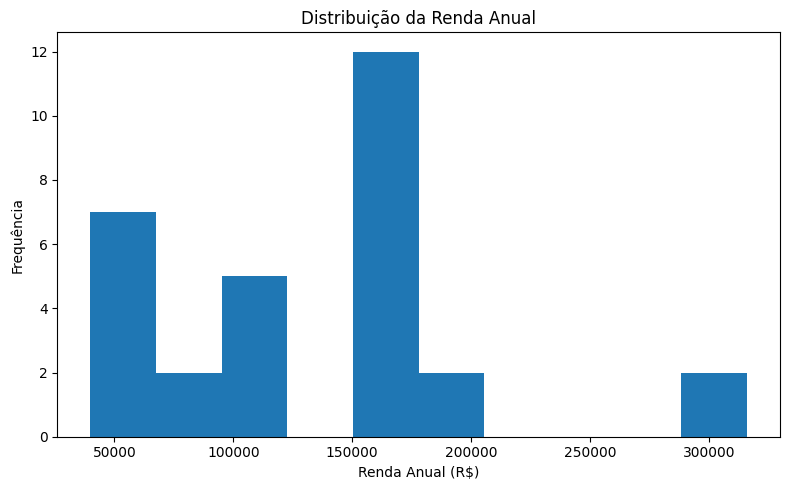

In [65]:
# ## 9. Visualizações (matplotlib puro)
# Observação: cada gráfico tem sua própria figura. Não definimos cores manualmente.
print("== 9) Gráficos ==")
# 9.1 Histograma da renda anual
plt.figure(figsize=(8,5))
plt.hist(df['renda_anual'].dropna(), bins=10)
plt.title('Distribuição da Renda Anual')
plt.xlabel('Renda Anual (R$)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_9504\1669955301.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_cat, labels=cats, showmeans=True)


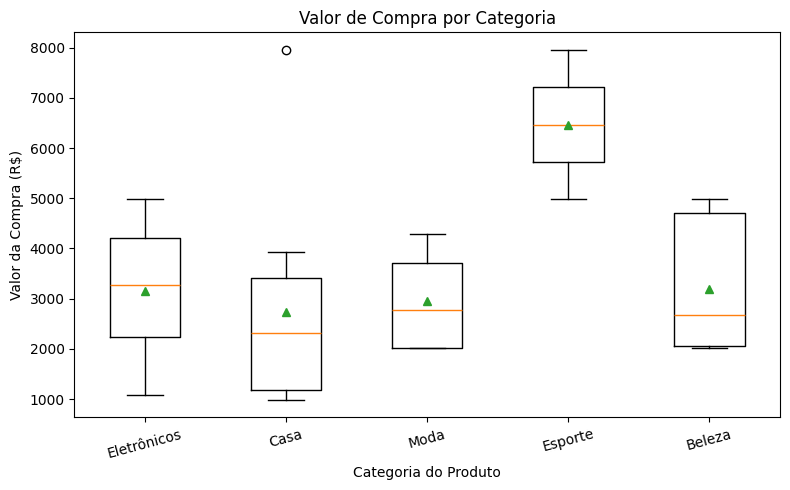

In [66]:
# 9.2 Boxplot do valor_compra por categoria_produto
# Preparar os dados por categoria
cats = df['categoria_produto'].dropna().unique()
data_by_cat = [df.loc[df['categoria_produto'] == c, 'valor_compra'].dropna().values for c in cats]

plt.figure(figsize=(8,5))
plt.boxplot(data_by_cat, labels=cats, showmeans=True)
plt.title('Valor de Compra por Categoria')
plt.xlabel('Categoria do Produto')
plt.ylabel('Valor da Compra (R$)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

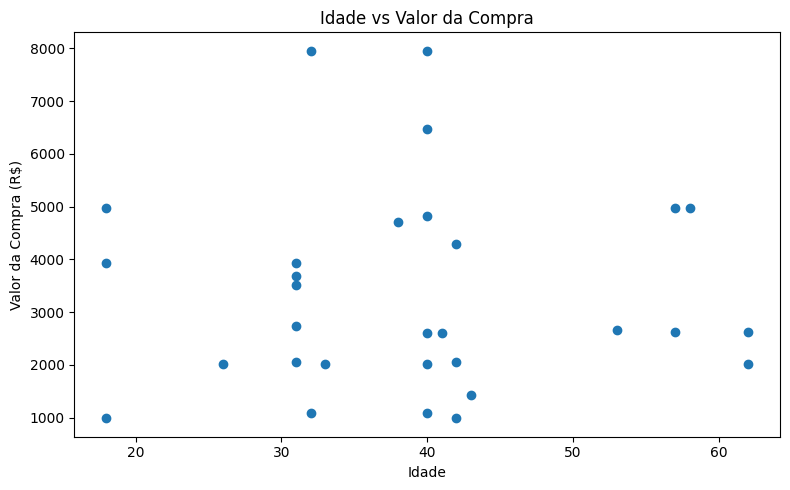

In [67]:
# 9.3 Scatterplot idade vs valor_compra
plt.figure(figsize=(8,5))
plt.scatter(df['idade'], df['valor_compra'])
plt.title('Idade vs Valor da Compra')
plt.xlabel('Idade')
plt.ylabel('Valor da Compra (R$)')
plt.tight_layout()
plt.show()

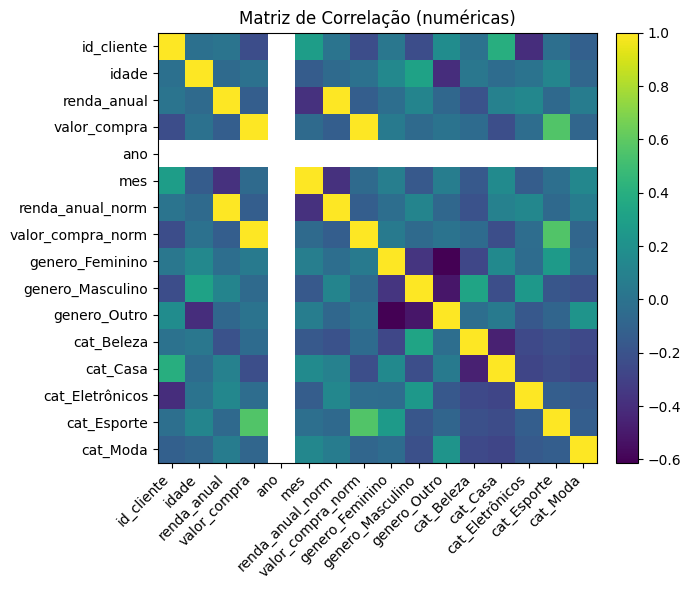

In [68]:
# 9.4 "Heatmap" simples de correlação (com imshow)
corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)
plt.figure(figsize=(7,6))
im = plt.imshow(corr, aspect='auto')
plt.title('Matriz de Correlação (numéricas)')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [69]:
# ## 10. Exportação do dataset limpo
print("== 10) Exportação ==")
saida = "dados_clientes_limpos.csv"
df.to_csv(saida, index=False, encoding="utf-8")
print(f"Arquivo '{saida}' exportado com sucesso!")

== 10) Exportação ==
Arquivo 'dados_clientes_limpos.csv' exportado com sucesso!
